In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
from sklearn.datasets import fetch_openml
mnist = mnist = fetch_openml('mnist_784', as_frame=False)

In [3]:
X, y = mnist["data"], mnist["target"].astype(float)
X.shape, y.shape

((70000, 784), (70000,))

In [4]:
Xtrain, Xtest, ytrain, ytest = X[:55000], X[55000:], y[:55000], y[55000:]

In [5]:
ytrain = np.where(ytrain %2==0,1, 0)
ytest = np.where(ytest  %2==0,1, 0)

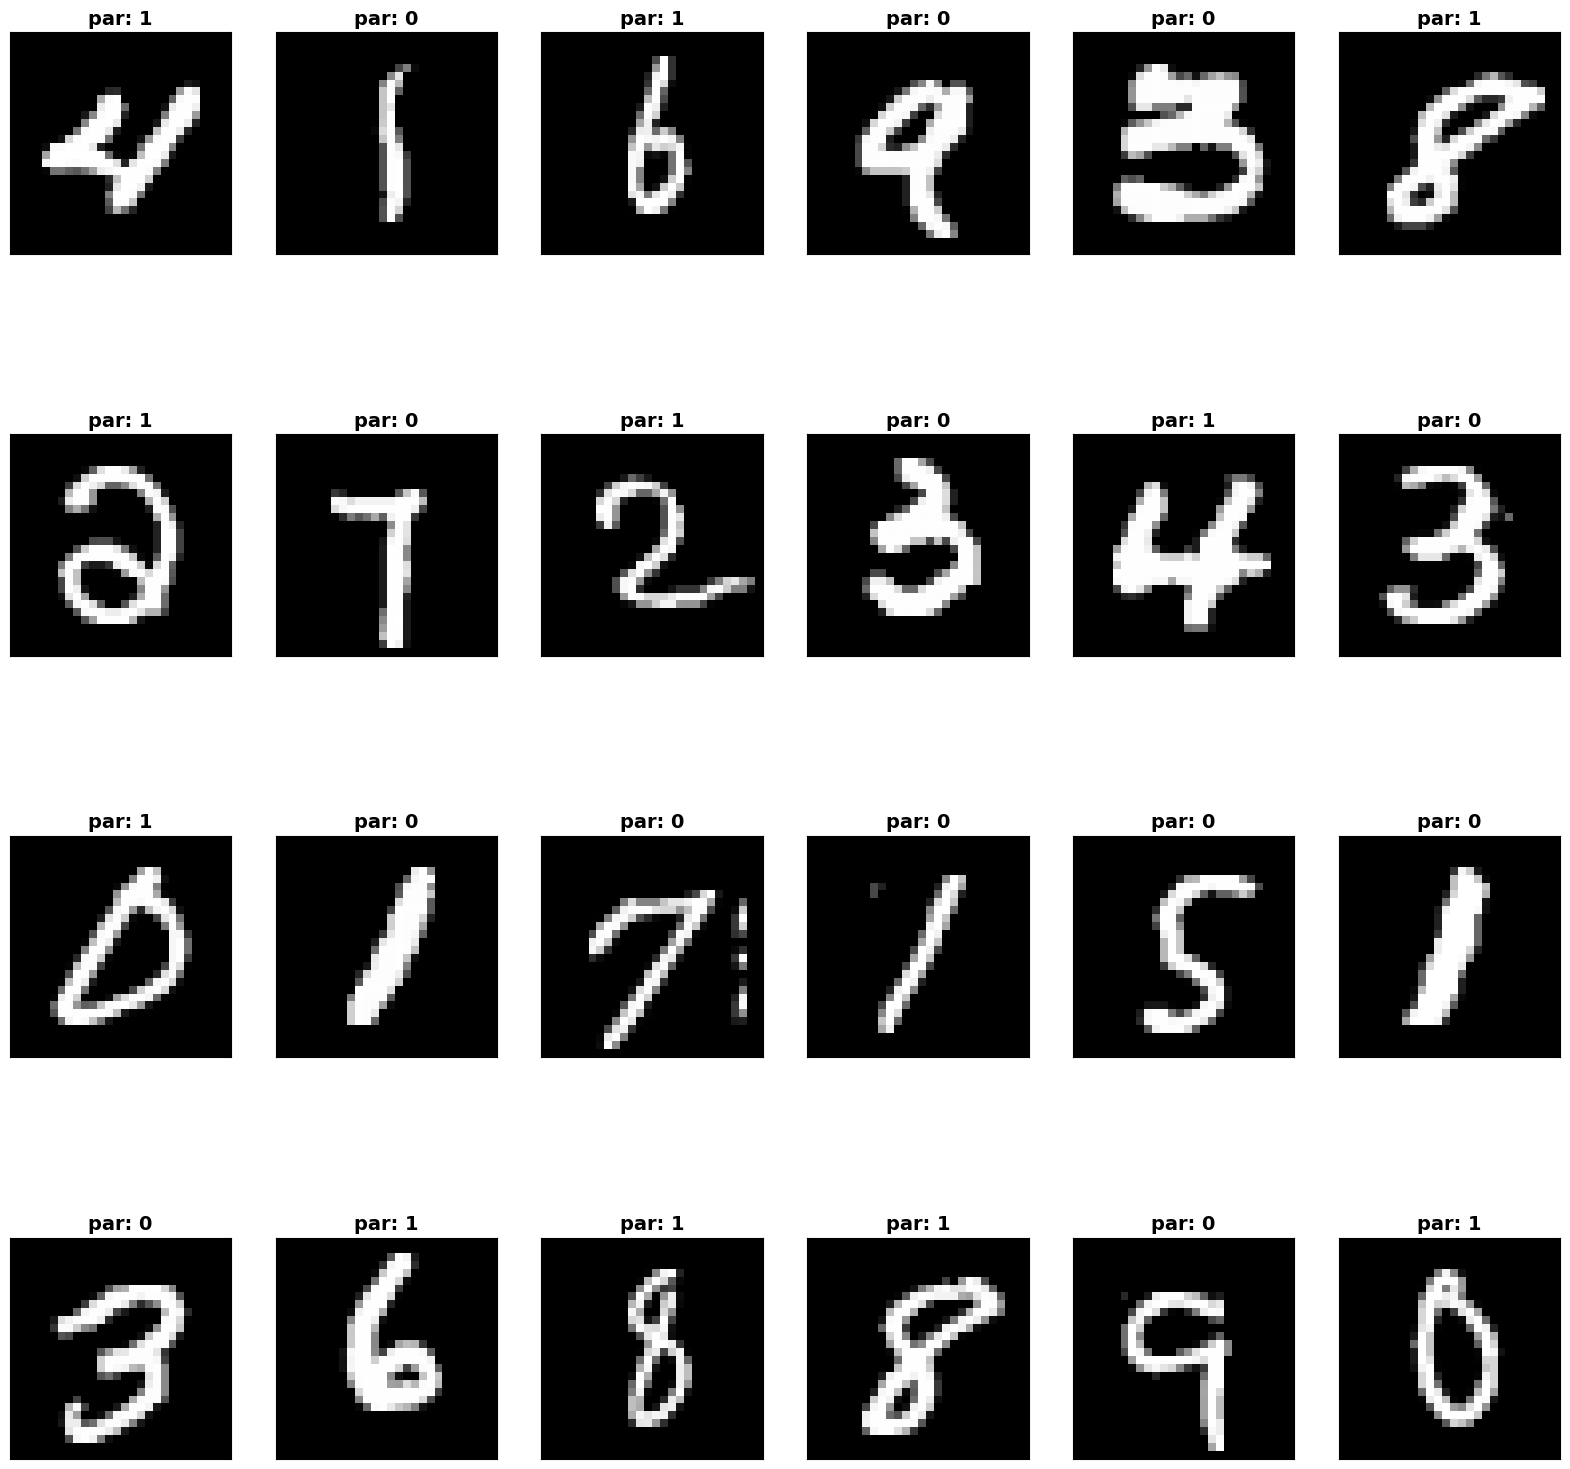

In [6]:
random_idx = np.random.randint(0,Xtrain.shape[0], size = 24)

plt.figure(figsize=[20,20])
for i in range(len(random_idx)):
    idx_i = random_idx[i]
    xval = Xtrain[idx_i, :].reshape(28,28)
    yval = ytrain[idx_i]
    plt.subplot(4,6,i+1)
    plt.imshow(xval, cmap = plt.cm.Greys_r)
    plt.xticks([])
    plt.yticks([])
    plt.title("par: "+str(yval), fontsize = 14, fontweight = 'bold')
plt.show()

In [7]:
print('Percentual de classe positiva: ',(ytrain.sum() / ytrain.size) * 100, '%')
print('Percentual de classe negativa: ',((ytrain.size-ytrain.sum()) / ytrain.size) * 100, '%')

Percentual de classe positiva:  49.154545454545456 %
Percentual de classe negativa:  50.84545454545455 %


In [8]:
 def sigmoid(t):
    return 1 / (1 + np.exp(-t))

In [9]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(Xtrain, ytrain)

LogisticRegression()

In [10]:
logreg.predict(Xtrain)

array([0, 1, 1, ..., 1, 1, 1])

In [11]:
logreg.predict_proba(Xtrain)

array([[0.99822145, 0.00177855],
       [0.070691  , 0.929309  ],
       [0.22019018, 0.77980982],
       ...,
       [0.00949744, 0.99050256],
       [0.31642436, 0.68357564],
       [0.01305648, 0.98694352]])

In [12]:
logreg.predict_proba(Xtrain)[0, ]

array([0.99822145, 0.00177855])

In [13]:
logreg.predict(Xtrain)[:20]

array([0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0])

In [14]:
ytrain[:20]

array([0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0])

In [15]:
predicoes = logreg.predict(Xtrain)

qtd_acertos = (predicoes == ytrain).sum()
total_inst = ytrain.size

acuracia_sgd = qtd_acertos / total_inst
print("acurácia - em dados de treino - da regressão logística foi de : ", acuracia_sgd)

acurácia - em dados de treino - da regressão logística foi de :  0.8989454545454545


In [16]:
from sklearn.metrics import accuracy_score

In [17]:
accuracy_score(y_true = ytrain, y_pred = logreg.predict(Xtrain))

0.8989454545454545

In [18]:
from sklearn.model_selection import KFold

In [19]:
kf = KFold(n_splits = 5)

In [20]:
classif__ = LogisticRegression() 
lista_acuracia_treino = []
lista_acuracia_validacao = []

for train_index, val_index in kf.split(Xtrain, ytrain):
    
    Xtrain_folds = Xtrain[train_index]
    ytrain_folds = ytrain[train_index]
    Xval_fold = Xtrain[val_index]
    yval_fold = ytrain[val_index]
    
    classif__.fit(Xtrain_folds, ytrain_folds)
    
    pred_treino = classif__.predict(Xtrain_folds)
    pred_validacao = classif__.predict(Xval_fold)
    
    lista_acuracia_treino.append(accuracy_score(y_pred = pred_treino, y_true = ytrain_folds))
    lista_acuracia_validacao.append(accuracy_score(y_pred = pred_validacao, y_true = yval_fold))

In [21]:
print("acurácias em treino: \n", lista_acuracia_treino, " \n| média: ", np.mean(lista_acuracia_treino))
print()
print("acurácias em validação: \n", lista_acuracia_validacao, " \n| média: ", np.mean(lista_acuracia_validacao))


acurácias em treino: 
 [0.8980454545454546, 0.9018863636363637, 0.8996136363636363, 0.898159090909091, 0.9005909090909091]  
| média:  0.899659090909091

acurácias em validação: 
 [0.8978181818181818, 0.8867272727272727, 0.8928181818181818, 0.9012727272727272, 0.89]  
| média:  0.8937272727272727


In [22]:
from sklearn.metrics import confusion_matrix

In [23]:
logreg = LogisticRegression() 
logreg.fit(Xtrain, ytrain)

confusion_matrix(y_true = ytrain, y_pred = logreg.predict(Xtrain))

array([[25110,  2855],
       [ 2703, 24332]], dtype=int64)

In [24]:
cm1 = confusion_matrix(y_true = ytrain, y_pred = logreg.predict(Xtrain))
cm1

array([[25110,  2855],
       [ 2703, 24332]], dtype=int64)

In [25]:
cm1[1,1] / cm1[1, :].sum()

0.9000184945441095

In [26]:
cm1[1,1] / cm1[:, 1].sum()

0.8949865744657373

In [27]:
from sklearn.metrics import precision_score, recall_score

In [28]:
recall_score(y_true = ytrain, y_pred = logreg.predict(Xtrain))

0.9000184945441095

In [29]:
 precision_score(y_true = ytrain, y_pred = logreg.predict(Xtrain))

0.8949865744657373

In [30]:
from sklearn.metrics import f1_score

In [31]:
 f1_score(y_true = ytrain, y_pred = logreg.predict(Xtrain))

0.8974954815388587

In [32]:
def validacao_cruzada(classificador, 
                      X, 
                      y, 
                      metrica, 
                      num_folds, 
                      print_info = False, 
                      nome_metrica = None):
    
    lista_metrica_treino = []
    lista_metrica_validacao = []
    
    kf = KFold(n_splits = num_folds)
    for train_index, val_index in kf.split(X, y):
        
        Xtrain_folds = X[train_index]
        ytrain_folds = y[train_index]
        Xval_fold = X[val_index]
        yval_fold = y[val_index]
        
        classificador.fit(Xtrain_folds, ytrain_folds)
        
        pred_treino = classificador.predict(Xtrain_folds)
        pred_validacao = classificador.predict(Xval_fold)
        
        lista_metrica_treino.append(metrica(y_pred = pred_treino, y_true = ytrain_folds))
        lista_metrica_validacao.append(metrica(y_pred = pred_validacao, y_true = yval_fold))
        
    if print_info:
        print("Métrica: " + nome_metrica)
        print('média treino:', np.mean(lista_metrica_treino))
        print('média validação:', np.mean(lista_metrica_validacao))
        
    return lista_metrica_treino, lista_metrica_validacao

In [33]:
for metrica, nome_metrica in zip([precision_score, recall_score, f1_score], ['Precision', 'Recall', 'F1']):
    l1, l2 = validacao_cruzada(classificador = LogisticRegression(),
                 X = Xtrain, 
                 y = ytrain, 
                 metrica = metrica, 
                 num_folds = 5,
                 print_info = True,
                 nome_metrica = nome_metrica) 

Métrica: Precision
média treino: 0.8952026525925862
média validação: 0.8888944823264191
Métrica: Recall
média treino: 0.9013836778804676
média validação: 0.8956924916553965
Métrica: F1
média treino: 0.8982820003441787
média validação: 0.8922737614632508


In [34]:
logreg = LogisticRegression()

logreg.fit(Xtrain, ytrain)

LogisticRegression()

In [35]:
prob_class_1 = logreg.predict_proba(Xtrain)[:, 1]  

In [36]:
limiares = np.linspace(0.05,0.95,20)

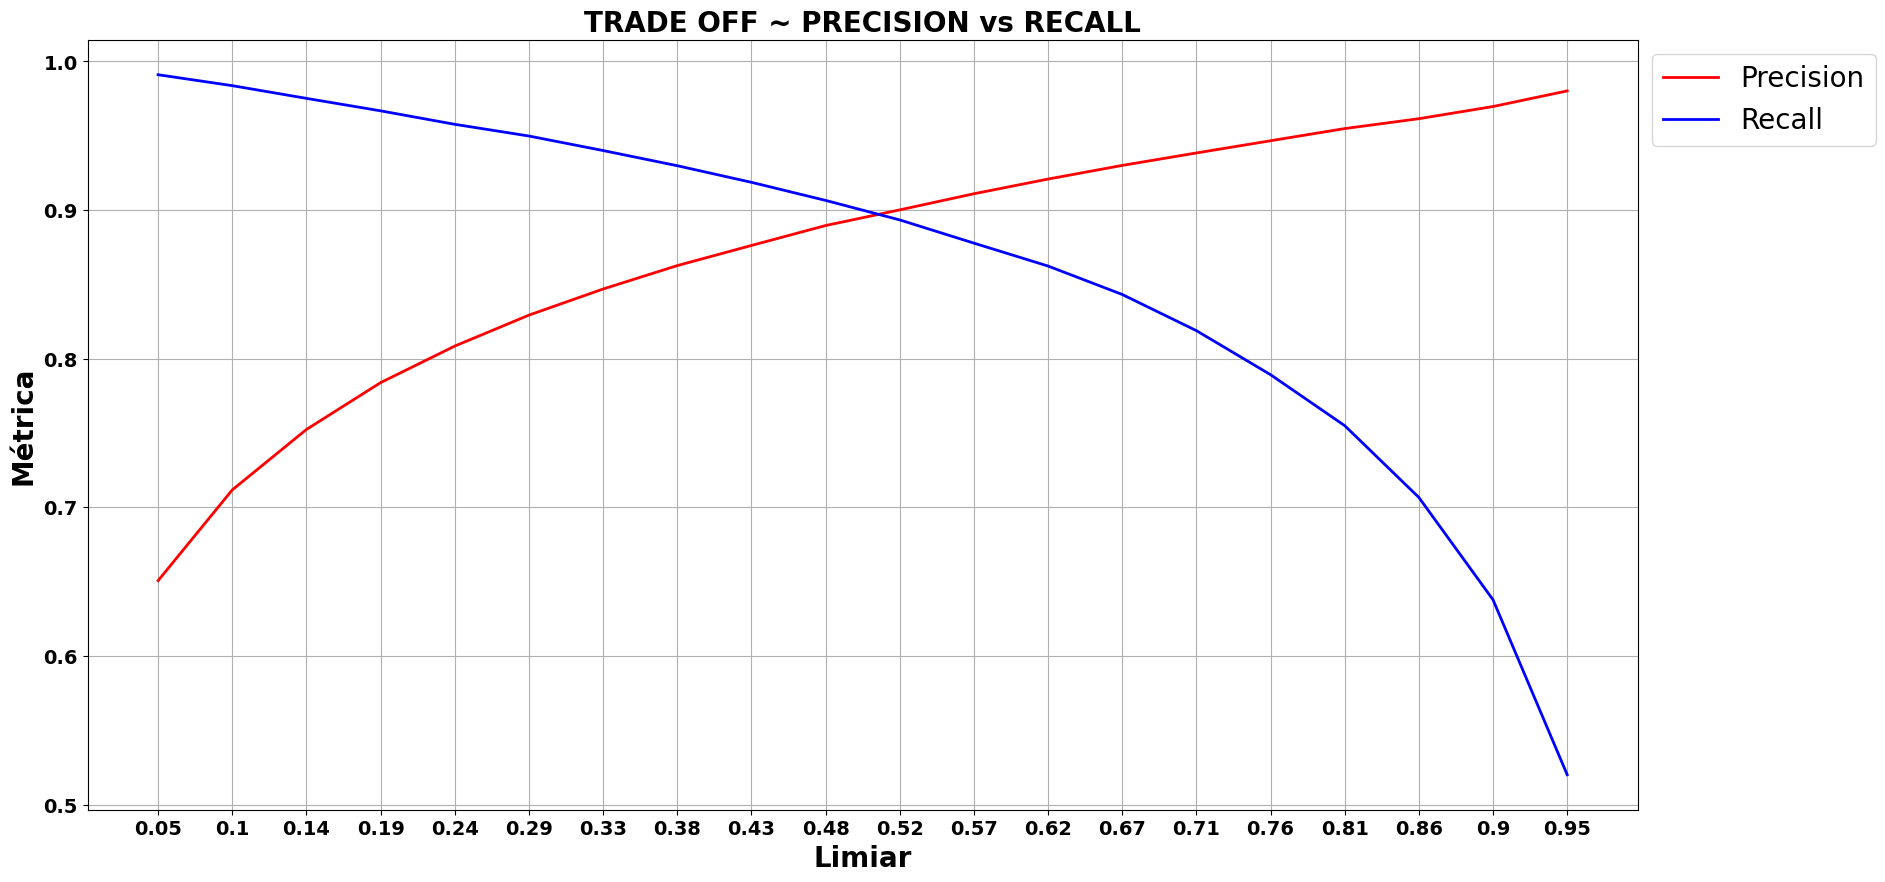

In [37]:
precision_list = []
recall_list = []

for t in limiares:
    
    pred_t = np.where(prob_class_1 > t, 1, 0)
    
    precision_t = precision_score(y_true = ytrain, y_pred = pred_t)
    recall_t = recall_score(y_true = ytrain, y_pred = pred_t)
    
    precision_list.append(precision_t)
    recall_list.append(recall_t)
    
    
plt.figure(figsize=[20,10])
plt.plot(range(len(limiares)), precision_list, c = 'red', label = 'Precision', lw = 2)
plt.plot(range(len(limiares)), recall_list, c = 'blue', label = 'Recall', lw = 2)
plt.xticks(range(len(limiares)), limiares.round(2), fontweight = 'bold', fontsize = 14)
plt.yticks(fontweight = 'bold', fontsize = 14)
plt.legend(fontsize = 20, bbox_to_anchor = [1,1])
plt.grid()
plt.xlabel("Limiar", fontsize = 20, fontweight = 'bold')
plt.ylabel("Métrica", fontsize = 20, fontweight = 'bold')
plt.title("TRADE OFF ~ PRECISION vs RECALL", fontsize = 20, fontweight = 'bold')
plt.show()

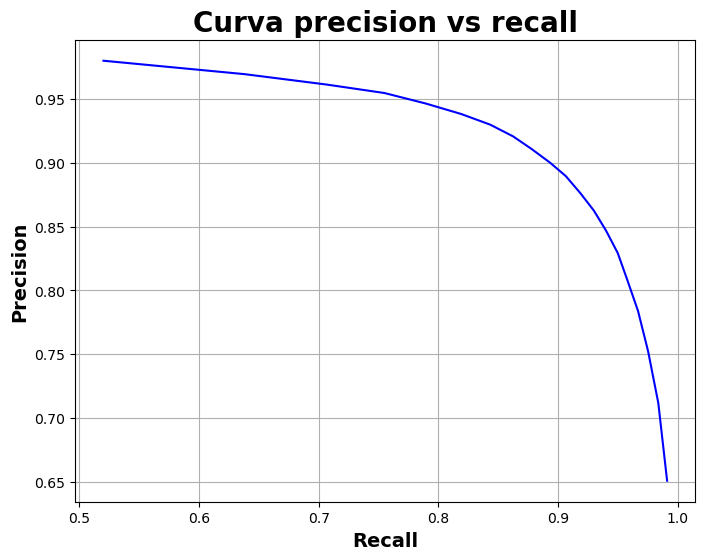

In [38]:
plt.figure(figsize=[8,6])
plt.plot(recall_list, precision_list, c = 'blue')
plt.xlabel("Recall", fontsize = 14, fontweight = 'bold')
plt.ylabel("Precision", fontsize = 14, fontweight = 'bold')
plt.title("Curva precision vs recall", fontsize = 20, fontweight = 'bold')
plt.grid()
plt.show()

In [39]:
for t in np.arange(0.1, 1.0, 0.1): 
    print('limiar: ', np.round(float(t), 2))
    print("confusion matrix:" )
    preds = np.where(prob_class_1 > t, 1, 0)
    print(confusion_matrix(y_pred = preds, y_true = ytrain))
    print('======================= \n')

limiar:  0.1
confusion matrix:
[[17331 10634]
 [  453 26582]]

limiar:  0.2
confusion matrix:
[[20978  6987]
 [  937 26098]]

limiar:  0.3
confusion matrix:
[[22900  5065]
 [ 1429 25606]]

limiar:  0.4
confusion matrix:
[[24168  3797]
 [ 2018 25017]]

limiar:  0.5
confusion matrix:
[[25110  2855]
 [ 2703 24332]]

limiar:  0.6
confusion matrix:
[[25848  2117]
 [ 3560 23475]]

limiar:  0.7
confusion matrix:
[[26441  1524]
 [ 4719 22316]]

limiar:  0.8
confusion matrix:
[[26963  1002]
 [ 6454 20581]]

limiar:  0.9
confusion matrix:
[[27421   544]
 [ 9653 17382]]



In [39]:
def validacao_cruzada(classificador, 
                      X, 
                      y, 
                      metrica, 
                      num_folds  , 
                      limiar = 0.5, 
                      print_info = False, 
                      nome_metrica = None):
    
    lista_metrica_treino = []
    lista_metrica_validacao = []
    kf = KFold(n_splits = num_folds)
    for train_index, val_index in kf.split(X, y):
        Xtrain_folds = X[train_index]
        ytrain_folds = y[train_index]
        Xval_fold = X[val_index]
        yval_fold = y[val_index]
        classificador.fit(Xtrain_folds, ytrain_folds)
        
        #alteração nesta parte! agora, primeiro calculamos a probabilidade e na sequência usamos o valor do limiar
        prob_class1_treino = classificador.predict_proba(Xtrain_folds)[:,1]
        prob_class1_validacao = classificador.predict_proba(Xval_fold)[:,1]
        pred_treino = np.where(prob_class1_treino > limiar, 1, 0)
        pred_validacao = np.where(prob_class1_validacao > limiar, 1, 0)
        
        lista_metrica_treino.append(metrica(y_pred = pred_treino, y_true = ytrain_folds))
        lista_metrica_validacao.append(metrica(y_pred = pred_validacao, y_true = yval_fold))
    if print_info:
        print("Métrica: " + nome_metrica)
        print('média treino:', np.mean(lista_metrica_treino))
        print('média validação:', np.mean(lista_metrica_validacao))
    return lista_metrica_treino, lista_metrica_validacao

In [40]:
print("Testando o limiar 0.5:")
lt, lv = validacao_cruzada(classificador = LogisticRegression(), 
                           X = Xtrain, 
                           y = ytrain, 
                           metrica = f1_score,
                           num_folds = 5, 
                           limiar = 0.5,
                           print_info = True, 
                           nome_metrica = 'F1')

Testando o limiar 0.5:
Métrica: F1
média treino: 0.8982820003441787
média validação: 0.8922737614632508


In [41]:
print("Testando o limiar 0.15:")
lt, lv = validacao_cruzada(classificador = LogisticRegression(), 
                           X = Xtrain, 
                           y = ytrain, 
                           metrica = f1_score,
                           num_folds = 5, 
                           limiar = 0.15,
                           print_info = True, 
                           nome_metrica = 'F1')

Testando o limiar 0.15:
Métrica: F1
média treino: 0.8523250541792464
média validação: 0.8490339609509883


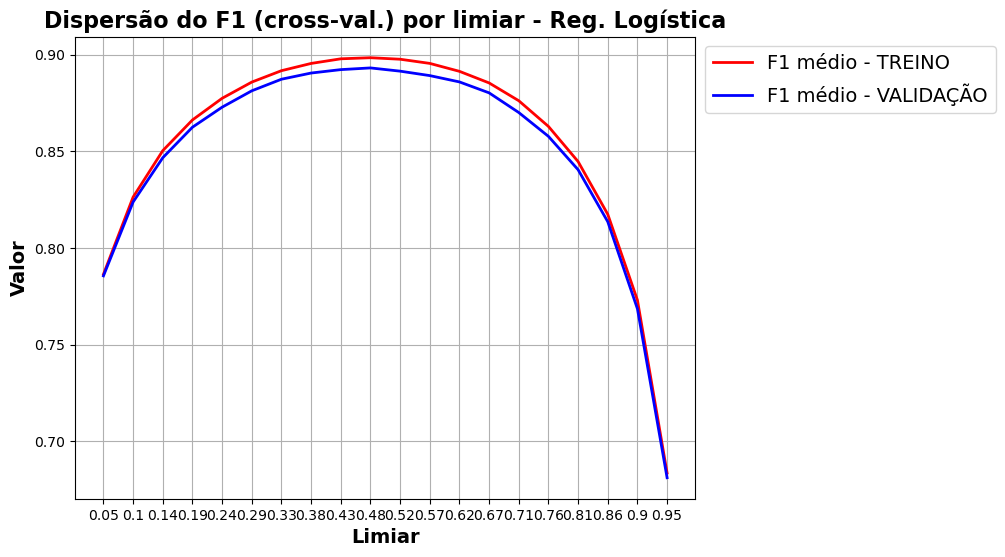

In [42]:
lista_media_metrica_treino = []
lista_media_metrica_validacao = []



for t in limiares:
    
    lt, lv = validacao_cruzada(classificador = LogisticRegression(), 
                                X = Xtrain, 
                                y = ytrain, 
                                metrica = f1_score,
                                num_folds = 5, 
                                limiar = t)
    
    lista_media_metrica_treino.append(np.mean(lt))
    lista_media_metrica_validacao.append(np.mean(lv))
    
plt.figure(figsize=[8,6])
plt.plot(range(len(limiares)), lista_media_metrica_treino, c = 'red', label = 'F1 médio - TREINO', lw = 2)
plt.plot(range(len(limiares)), lista_media_metrica_validacao, c = 'blue', label = 'F1 médio - VALIDAÇÃO', lw = 2)
plt.xticks(range(len(limiares)), limiares.round(2))
plt.legend(fontsize = 14, bbox_to_anchor = [1,1])
plt.grid()
plt.xlabel("Limiar", fontsize = 14, fontweight = 'bold')
plt.ylabel("Valor", fontsize = 14, fontweight = 'bold')
plt.title("Dispersão do F1 (cross-val.) por limiar - Reg. Logística", fontsize = 16, fontweight = 'bold')
plt.show()

In [58]:
print("Testando o limiar 0.5:")
lt, lv = validacao_cruzada(classificador = LogisticRegression(), 
                           X = Xtrain, 
                           y = ytrain, 
                           metrica = f1_score,
                           num_folds = 5, 
                           limiar = 0.48,
                           print_info = True, 
                           nome_metrica = 'F1')

Testando o limiar 0.5:
Métrica: F1
média treino: 0.8984662219584647
média validação: 0.8930147338405863


In [43]:
logreg = LogisticRegression()
logreg.fit(Xtrain, ytrain)

LogisticRegression()

In [44]:
from sklearn.metrics import roc_curve

In [45]:
fpr, tpr, thresholds = roc_curve(y_true = ytest, y_score = logreg.predict_proba(Xtest)[:, 1])

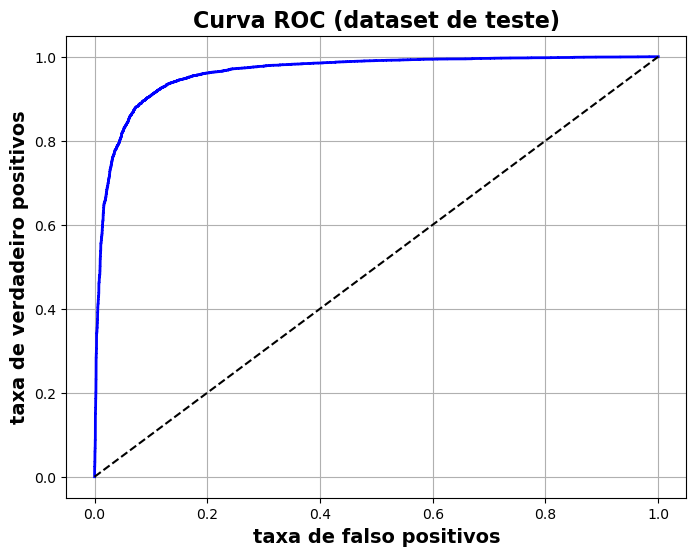

In [46]:
plt.figure(figsize=[8,6])
plt.plot(fpr, tpr, c = 'blue', lw = 2)
plt.title("Curva ROC (dataset de teste)", fontsize = 16, fontweight = 'bold')
plt.xlabel("taxa de falso positivos", fontsize = 14, fontweight = 'bold')
plt.ylabel("taxa de verdadeiro positivos", fontsize = 14, fontweight = 'bold')
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal
plt.grid()
plt.show()

In [47]:
from sklearn.metrics import roc_auc_score

In [48]:
roc_auc_score(y_true = ytest, y_score = logreg.predict_proba(Xtest)[:, 1])

0.9623707180935108

In [49]:
from sklearn.neighbors import KNeighborsClassifier

In [50]:
for i in range(1,10):
    knn = KNeighborsClassifier(n_neighbors= i)
    knn.fit(Xtrain,ytrain)
    acuracias = accuracy_score(y_true = ytrain, y_pred = knn.predict(Xtrain))
    
    print("numeros de vizinhos", i ,"valor da acurácias",acuracias)

numeros de vizinhos 1 valor da acurácias 1.0
numeros de vizinhos 2 valor da acurácias 0.9898545454545454
numeros de vizinhos 3 valor da acurácias 0.9923272727272727
numeros de vizinhos 4 valor da acurácias 0.9878
numeros de vizinhos 5 valor da acurácias 0.9893818181818181
numeros de vizinhos 6 valor da acurácias 0.9863272727272727
numeros de vizinhos 7 valor da acurácias 0.9872
numeros de vizinhos 8 valor da acurácias 0.9846181818181818
numeros de vizinhos 9 valor da acurácias 0.9856181818181818


In [51]:
for i in range(1,10):
    knn = KNeighborsClassifier(n_neighbors= i)
    knn.fit(Xtrain,ytrain)
    con_matrix = confusion_matrix(y_true = ytrain, y_pred = knn.predict(Xtrain))
    
print("numeros de vizinho:", i)
print("*****" * 20)
print(con_matrix)

numeros de vizinho: 9
****************************************************************************************************
[[27759   206]
 [  585 26450]]


In [52]:
for i in range(1,10):
    knn = KNeighborsClassifier(n_neighbors= i)
    knn.fit(Xtrain,ytrain)
    recall = recall_score(y_true = ytrain, y_pred = knn.predict(Xtrain))
    preci = precision_score(y_true = ytrain, y_pred = knn.predict(Xtrain))
    
    print("numeros de vizinhos", i ,"recall:",recall,"|","precision:",preci)
    

numeros de vizinhos 1 recall: 1.0 | precision: 1.0
numeros de vizinhos 2 recall: 0.9793600887738118 | precision: 1.0
numeros de vizinhos 3 recall: 0.989458109857592 | precision: 0.9949046007364154
numeros de vizinhos 4 recall: 0.9783983724801184 | precision: 0.9967216821162107
numeros de vizinhos 5 recall: 0.9846865174773441 | precision: 0.993654585495129
numeros de vizinhos 6 recall: 0.9768818198631404 | precision: 0.9952142291894336
numeros de vizinhos 7 recall: 0.9813574995376364 | precision: 0.9925180502038832
numeros de vizinhos 8 recall: 0.9745884963935639 | precision: 0.9940015844871166
numeros de vizinhos 9 recall: 0.9783613833918994 | precision: 0.9922719087635054


In [54]:
for i in range(1,10):
    knn = KNeighborsClassifier(n_neighbors= i)
    knn.fit(Xtrain,ytrain)
    f1 = f1_score(y_true = ytrain, y_pred =knn.predict(Xtrain))
    
    print("numeros de vizinhos", i ,"f1:",f1)
    
        

numeros de vizinhos 1 f1: 1.0
numeros de vizinhos 2 f1: 0.9895724323516222
numeros de vizinhos 3 f1: 0.9921738807907718
numeros de vizinhos 4 f1: 0.9874750340656674
numeros de vizinhos 5 f1: 0.9891502247984246
numeros de vizinhos 6 f1: 0.9859628163966251
numeros de vizinhos 7 f1: 0.9869062232637726
numeros de vizinhos 8 f1: 0.9841993201598744
numeros de vizinhos 9 f1: 0.9852675494961912


In [55]:
fpr_1, tpr_1, thresholds_1 = roc_curve(y_true = ytest, y_score = knn.predict_proba(Xtest)[:, 1])

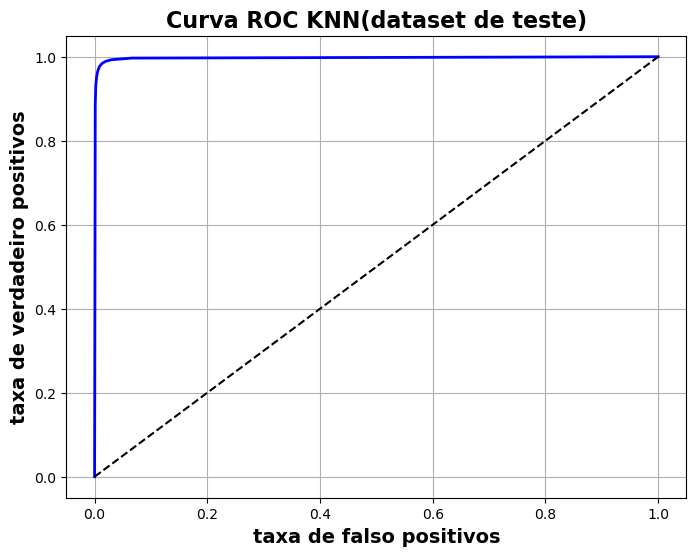

In [56]:
plt.figure(figsize=[8,6])
plt.plot(fpr_1, tpr_1, c = 'blue', lw = 2)
plt.title("Curva ROC KNN(dataset de teste)", fontsize = 16, fontweight = 'bold')
plt.xlabel("taxa de falso positivos", fontsize = 14, fontweight = 'bold')
plt.ylabel("taxa de verdadeiro positivos", fontsize = 14, fontweight = 'bold')
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal
plt.grid()
plt.show()

In [57]:
print("Testando o limiar 0.5:")
lt, lv = validacao_cruzada(classificador = KNeighborsClassifier(), 
                           X = Xtrain, 
                           y = ytrain, 
                           metrica = f1_score,
                           num_folds = 5, 
                           limiar = 0.5,
                           print_info = True, 
                           nome_metrica = 'F1')

Testando o limiar 0.5:
Métrica: F1
média treino: 0.9882974787908395
média validação: 0.9810787481173577
